## <span style="color:blue"> Lezione 2 </span>



In [1]:

import matplotlib.pyplot as plt
import numpy as np
import scipy.optimize as scipy


### <span style="color:DodgerBlue"> Esercizio 2.1  </span>

### Metodo Monte Carlo per il calcolo degli integrali


Sia data una funzione $f: [a,b] \to \mathbb{R} $ con valore medio $\mu=\langle f(x) \rangle _{[a,b]} $ e varianza $ \sigma^2 = \langle (f(x)- \mu)^2 \rangle _{[a,b]}< +\infty $ (dove $\langle \cdot  \rangle _{[a,b]} $ indica il valore medio calcolato per $x$ distribuita uniformemente nell'intervallo $[a,b]$). 

Per $N \gg 1$ vale $$ \int _a^b f(x) \mathrm{d} x = (b-a) \langle f \rangle _{[a,b]} \simeq (b-a) \frac{1}{N} \sum_{i=1}^N f(x_i), $$ 

con $x_i$ variabili random uniformemente estratte nell'intervallo $[a,b]$. Supponendo che siano indipendenti e sfruttando l'ipotesi di varianza finita, si può applicare il teorema del limite centrale per ottenere l'errore sull'integrale: $\epsilon \propto \sigma / \sqrt{N}$. 

Si può generalizzare ad una distribuzione di probabilità $p$ e dominio $\Omega$ qualsiasi: date $N$ $\vec{x}_i$ variabili indipendenti distribuite secondo $p(\vec{x})$,  $$ \frac{1}{N} \sum_{i=1}^N g(\vec{x}_i) \substack{\simeq \\ N\gg 1 } \int_{\Omega} g(\vec{x}) p(\vec{x}) \, \mathrm{d} \vec{x}  $$

e l'errore scala come $1 / \sqrt{N}$, indipendentemente dal numero di dimensioni. Ciò rende il metodo Monte Carlo molto conveniente per situazioni ad alta dimensionalità.


L'efficienza del metodo Monte Carlo può essere aumentata sfruttando il metodo dell'_importance sampling_. Se si considera una distribuzione di probabilità $d(\vec{x})$  è  possibile riscrivere: $$ I=\int_{\Omega} g(\vec{x}) p(\vec{x})  \, \mathrm{d} \vec{x}= \int_{\Omega} \left[\frac{g(\vec{x}) p(\vec{x})}{d(\vec{x})} \right] d(\vec{x})  \, \mathrm{d} \vec{x} ,$$ 

dove deve valere $h(\vec{x})=\frac{g(\vec{x}) p(\vec{x})}{d(\vec{x})} < +\infty  $ eccetto che su un insieme di misura nulla. 

Scegliendo opportunatamente la funzione $d(\vec{x})$ è possibile ridurre l'errore sul calcolo dell'integrale.



Si stima il valore dell'integrale: $$I=\frac{\pi}{2} \int_0^1 \cos\left(\frac{\pi x}{2}\right) \, \mathrm{d}x =1 $$ con il metodo Monte Carlo. Dapprima, si campiona $x$ con una distribuzione uniforme tra $[0,1)$, dopodichè si applica l'_importance sampling_  con  $d(x)=2(1-x)$ su $[0,1)$. Per campionarla si può invertire la distribuzione cumulativa: dato $u$ estratto uniformemente da $[0,1)$, $x=1-\sqrt{1-u}$ segue la distribuzione richiesta. 

Si sono campionati $M=100000$ punti, suddivisi in $N=100$ blocchi per l'applicazione del metodo del _data blocking_ nel calcolo delle incertezze. 


Nella cella sottostante è riportato il codice che genera il grafico del confronto della stima dell'integrale calcolata con i due metodi (a sinistra), e il grafico del confronto tra $f(x)=\frac{\pi}{2} \cos\left(\frac{\pi x}{2}\right) $, $p(x)= 1$ (distribuzione uniforme su $[0,1)$) e $d(x)=2(1-x) $ su $[0,1)$. 

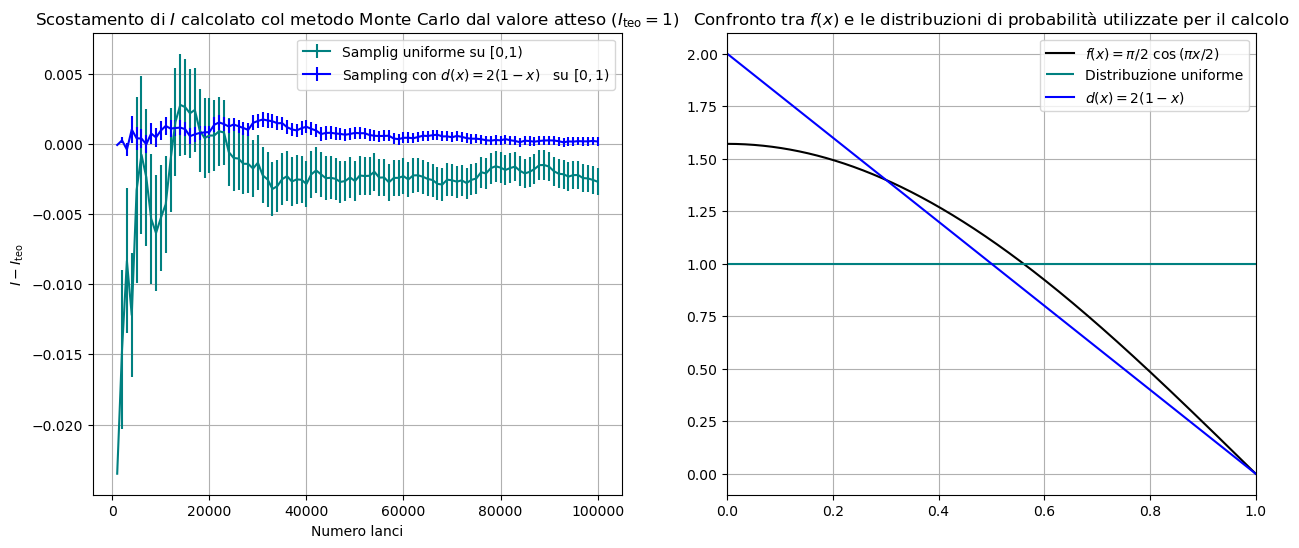

In [5]:

fig,axs =plt.subplots(1,2,figsize=[15,6])

#grafico integrale 

M=100000 #numero estrazioni
N=100 #numero blocchi

I_u,error_u,I_is,error_is=np.loadtxt("l_02_es_1/results.csv", usecols=(0,1,2,3), delimiter=',', unpack='true',skiprows=1) #carica i dati, saltando la riga del titolo

n=np.arange(1,N+1) #progressivo dei blocchi
n*=int(M/N) #numero estrazioni 

#traccia il grafico dello scostamento dell'integrale dal valore atteso in funzione del numero di blocchi, con le rispettive barre di errore
axs[0].errorbar(n,I_u-1,error_u,color="teal",label="Samplig uniforme su [0,1)") #sampling uniforme
axs[0].errorbar(n,I_is-1,error_is,color="blue",label=r"Sampling con $d(x)=2(1-x)$   su $ [0,1)$") #importance sampling


axs[0].set_title(r"Scostamento di $I$ calcolato col metodo Monte Carlo dal valore atteso ($I_{\mathrm{teo}}=1$)")
axs[0].set_xlabel("Numero lanci")
axs[0].set_ylabel(r"$I-I_{\mathrm{teo}}$")
axs[0].legend()
axs[0].grid(True)

#grafico funzione e distribuzioni
x=np.linspace(0,1,1000)
f=np.pi/2*np.cos(np.pi*x/2)
p=2*(1-x)


axs[1].plot(x,f,color="black",label=r"$f(x)={\pi}/{2} \ \cos\left({\pi x}/{2}\right)$")
axs[1].hlines(1,0,1,color="teal",label="Distribuzione uniforme")
axs[1].plot(x,p,color="blue",label=r"$d(x)=2(1-x)$")

axs[1].set_xlim([0,1])
axs[1].grid(True)

axs[1].set_title("Confronto tra $f(x)$ e le distribuzioni di probabilità utilizzate per il calcolo")
axs[1].legend();



È evidente che la stima dell'integrale ottenuta campionando con $d(x)$ si discosta meno dal valore atteso ed ha una varianza inferiore rispetto a quella ottenuta campionando con una distribuzione uniforme. Nel grafico a destra si può notare come la distribuzione $d(x)$ sia molto più "simile" a $f(x)$ rispetto alla distribuzione uniforme. 

### <span style="color:DodgerBlue"> Esercizio 2.3 </span>

Per un random walk monodimensionale, vale l'equazione di diffusione: $$ \frac{\partial p_1(x,t)}{\partial t}=D \frac{\partial^2 p_1(x,t)}{\partial^2 x}$$
dove $D$ è la costante di diffusione. Se la distribuzione di probabilità iniziale è $p_1(x,t)=\delta(x)$ (ossia il random walk comincia in $x=0$ con certezza), si trova che $\langle x(t)\rangle =0$ e $\langle x(t)^2 \rangle = 2 D t$. Per un random walk discreto, con passi di lunghezza fissata $a$ ad intervalli regolari $\tau$, $D={a^2}/{2 \tau} $. Per cui, per un random walk discreto monodimensionale con partenza nell'origine, $ \sigma_x(n)^2 =  \langle x(n)^2 \rangle -\langle x(n) \rangle^2 =a^2 n$, con $n$ numero di passi.  

Sono dati due random walk in 3D: 
1. `Su una griglia`: ad ogni step il random walk può muoversi avanti o indietro di un passo $a=1$, in ciascuna direzione cartesiana, con egual probabilità.
2. `Nel continuo`: ad ogni step il random walk si muoverà di un passo $\vec{r}=(1,\theta,\phi)$ in coordinate sferiche, con $\theta \in[0,\pi)$ e $\phi \in[0,2\pi)$ estratti da una distribuzione uniforme.

Entrambi i random walk partono dall'origine.


Per $M=10000$ volte, suddivise in $N=100$ blocchi vengono generati i random walk 1. e 2. con $R=100$ steps ciascuno. Si calcola quindi: $$ A(i)=\sqrt{\langle|\vec{r}_i|^2\rangle} $$ per ogni step $i\in [1,100]$. Si procede nel modo seguente: 
1. Per ogni blocco, si generano $L=M/N$ random walk. 
2. Per ogni numero di passi $i \in [1,R]$, si calcola la radice quadrata della media di $|\vec{r}_i|^2$ sui $L$ random walk del blocco ($A(i)$)
3. Per ogni $i$, si calcola la media delle $N$ $A(i)$, e la sua varianza. 


Nella cella sottostante è presente il codice che genera la rappresentazione dei risultati trovati ($A(i)$ in funzione di $i$) e il fit con la funzione $E(i) = k \sqrt{i}$ 



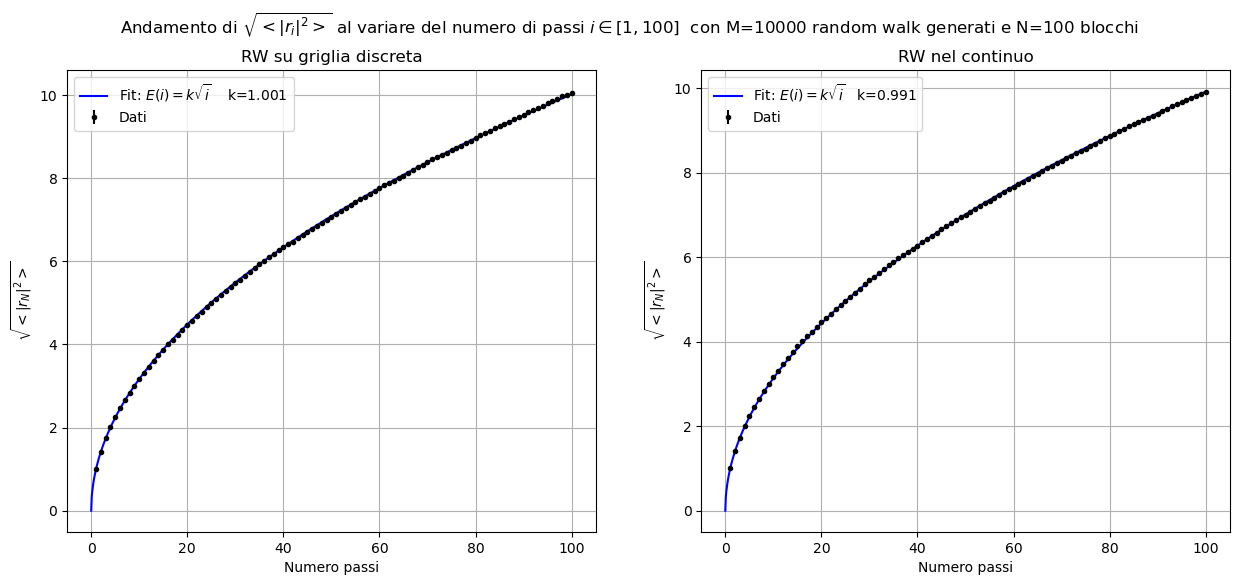

In [3]:

#funzione per il fit
def f(x,k): 
    return k*np.sqrt(x)

data_grid,error_grid,data_cont,error_cont=np.loadtxt("l_02_es_2/results.csv", usecols=(0,1,2,3), delimiter=',', unpack='true',skiprows=1) #carica i dati, saltando la riga del titolo

fig,axs=plt.subplots(1,2,figsize=[15,6])


M=10000 #numero random walk generati
N=100 #numero blocchi
R=100#numero step 


n=np.arange(1,R+1) #progressivo del numero di step 


#Random walk su griglia

axs[0].errorbar(n,data_grid,error_grid,marker=".",linestyle="none",color="black",label="Dati") #plot dati

#fit e relativo plot
k_fit_1=scipy.curve_fit(f,n,data_grid)[0][0] #fitta i dati alla funzione k*sqrt(x) e restituisce il parametro k
x=np.linspace(0,R,R*10)
axs[0].plot(x,f(x,k_fit_1),color="blue",label=rf"Fit: $E(i)=k \sqrt{{i}} $    k={k_fit_1:.3f} ") 

axs[0].set_title(fr"RW su griglia discreta")
axs[0].set_xlabel("Numero passi")
axs[0].set_ylabel(r"$\sqrt{<|r_N|^2>}$")
axs[0].legend()
axs[0].grid(True)


#Random walk nel continuo 

axs[1].errorbar(n,data_cont,error_cont,marker=".",linestyle="none",color="black",label="Dati") #plot dati

#fit e relativo plot
k_fit_2=scipy.curve_fit(f,n,data_cont)[0][0] #fitta i dati alla funzione k*sqrt(x) e restituisce il parametro k
x=np.linspace(0,R,R*10)
axs[1].plot(x,f(x,k_fit_2),color="blue",label=rf"Fit: $E(i)=k \sqrt{{i}} $   k={k_fit_2:.3f}")

axs[1].set_title(fr"RW nel continuo")
axs[1].set_xlabel("Numero passi")
axs[1].set_ylabel(r"$\sqrt{<|r_N|^2>}$")
axs[1].legend()
axs[1].grid(True)


plt.suptitle(rf"Andamento di $\sqrt{{<|r_i|^2>}}$ al variare del numero di passi $i\in [1,{R}]$  con M={M} random walk generati e N={N} blocchi")
plt.show()

Per entrambi i random walk, $\sigma_r(i)=\sqrt{\langle|\vec{r}_i|^2\rangle} \sim a \sqrt{i} $. Infatti, le costanti trovate col fit sono circa $1$, che è la lunghezza $a$ del passo. Questa è coerente, per quanto riportato sopra, con un comportamento diffusivo e indica un'estensione a più dimensioni di quanto discusso in una dimensione. 


Le barre di errore sono troppo piccole per essere visualizzate: vengono infatti coperte dall'estensione del marker utilizzato. È stato dunque rappresentato anche il grafico dei residui. 

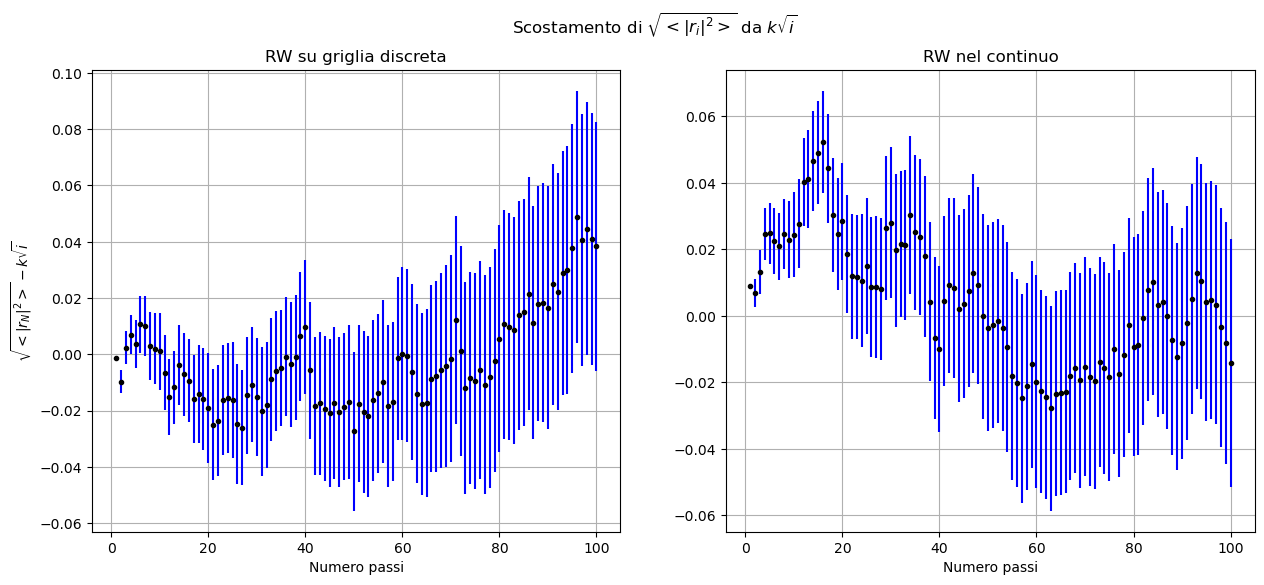

In [4]:

fig,axs=plt.subplots(1,2,figsize=[15,6])

axs[0].errorbar(n,data_grid-f(n,k_fit_1),error_grid,marker=".",linestyle="none",color="black",ecolor="blue") #plot dati

axs[0].set_title(fr"RW su griglia discreta")
axs[0].set_xlabel("Numero passi")
axs[0].set_ylabel(r"$\sqrt{<|r_N|^2>}- k\sqrt{i}$")
axs[0].grid(True)

axs[1].errorbar(n,data_cont-f(n,k_fit_2),error_cont,marker=".",linestyle="none",color="black",ecolor="blue") #plot dati
axs[1].set_title(fr"RW nel continuo")
axs[1].set_xlabel("Numero passi")
axs[0].set_ylabel(r"$\sqrt{<|r_N|^2>}- k\sqrt{i}$")
axs[1].grid(True)



plt.suptitle(rf"Scostamento di $\sqrt{{<|r_i|^2>}}$ da $ k\sqrt{{i}}$ ")
plt.show()